In [1]:
# === Cell 1: Bootstrap — local or Colab ===
import os, subprocess, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_PATH = '/content/cv-face-alignment'
    if not os.path.exists(REPO_PATH):
        subprocess.run(
            ['git', 'clone', 'https://github.com/wvb20/cv-face-alignment.git', REPO_PATH],
            check=True,
        )
    else:
        subprocess.run(['git', '-C', REPO_PATH, 'pull'], check=True)
else:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'config.py').exists():
            REPO_PATH = str(candidate)
            break
    else:
        raise RuntimeError('Could not find repo root.')

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')  # type: ignore
    get_ipython().run_line_magic('autoreload', '2')         # type: ignore
except Exception:
    pass

from src.runtime import configure_notebook_runtime
runtime = configure_notebook_runtime(REPO_PATH)
from src import config, data, evaluate, features, models, segment, effects

print('✓ Setup complete')
print(f'Workspace: {runtime.workspace_dir}')

✓ Setup complete
Workspace: /Users/willvaughn/Developer/cv-face-alignment


In [2]:
# === Cell 2: Load val data + cascade-predicted landmarks ===
# Create cascade landmarks for the val images.
# Using cascade for speed and accuracy vs CNN.

import time
images, points = data.load_train()
train_idx, val_idx = data.get_split()

X_train, y_train = images[train_idx], points[train_idx]
X_val,   y_val   = images[val_idx],   points[val_idx]

cascade = models.CascadedRidgeRegressor(n_stages=4, alpha=10.0, patch_size=16)
print('Training cascade for val landmark predictions...')
t0 = time.time()
cascade.fit(X_train, y_train, verbose=False)
y_pred_val = cascade.predict(X_val)
print(f'Done. {time.time() - t0:.1f}s')
print(f'Val NME: {evaluate.nme(y_pred_val, y_val).mean()*100:.2f}%')

Training cascade for val landmark predictions...
Done. 13.9s
Val NME: 3.86%


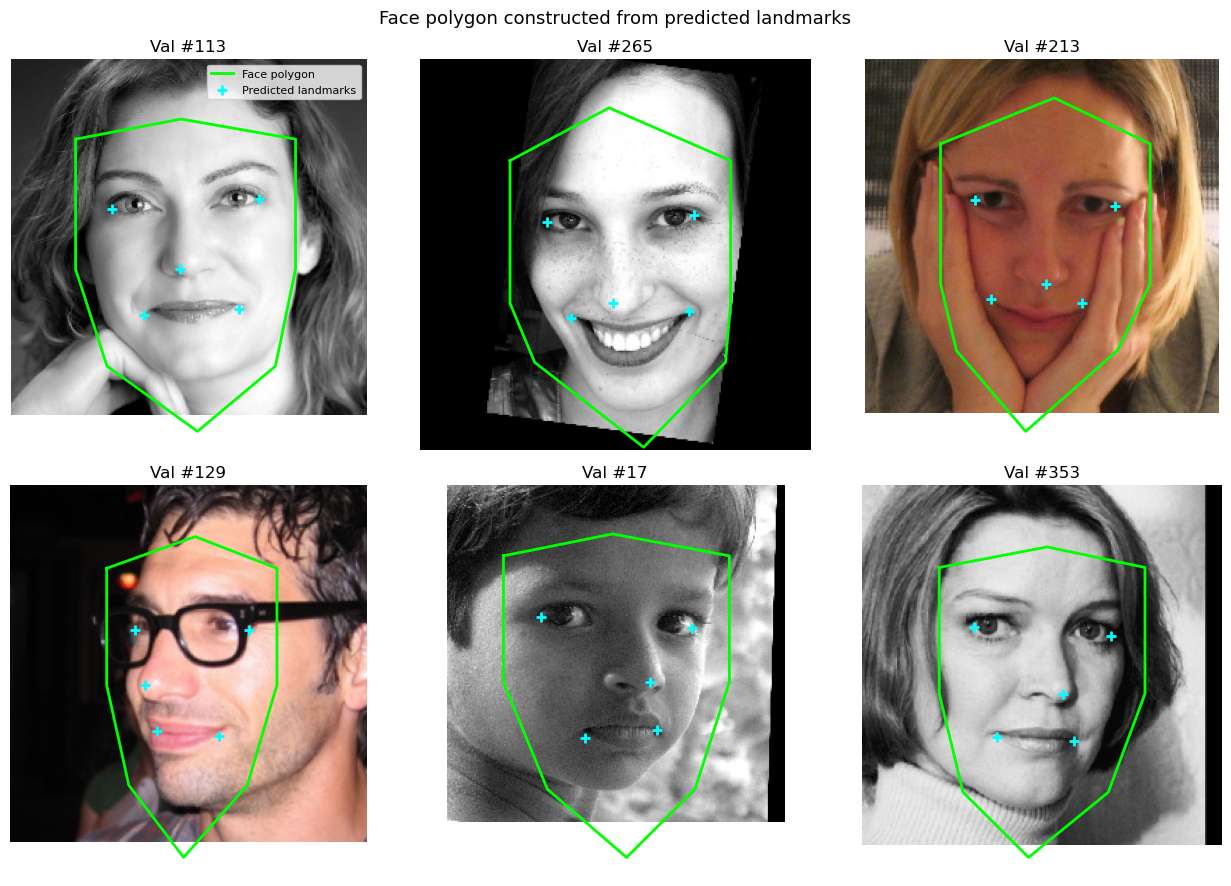

In [3]:
# === Cell 3: Visualise polygon outline on 6 val images ===
rng = np.random.default_rng(seed=0)
sample = rng.choice(len(X_val), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, i in zip(axes.flat, sample):
    img = X_val[i]
    pts = y_pred_val[i]
    polygon = segment.face_polygon_points(pts)

    ax.imshow(img)
    # Draw polygon outline (close it by appending first vertex)
    poly_closed = np.vstack([polygon, polygon[:1]])
    ax.plot(poly_closed[:, 0], poly_closed[:, 1], 'lime', linewidth=2,
            label='Face polygon')
    # Show landmarks
    ax.scatter(pts[:, 0], pts[:, 1], s=60, c='cyan', marker='+', linewidth=2,
               label='Predicted landmarks')
    ax.set_title(f'Val #{i}')
    ax.axis('off')
axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Face polygon constructed from predicted landmarks', fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/15_face_polygon.png',
            dpi=120, bbox_inches='tight')
plt.show()

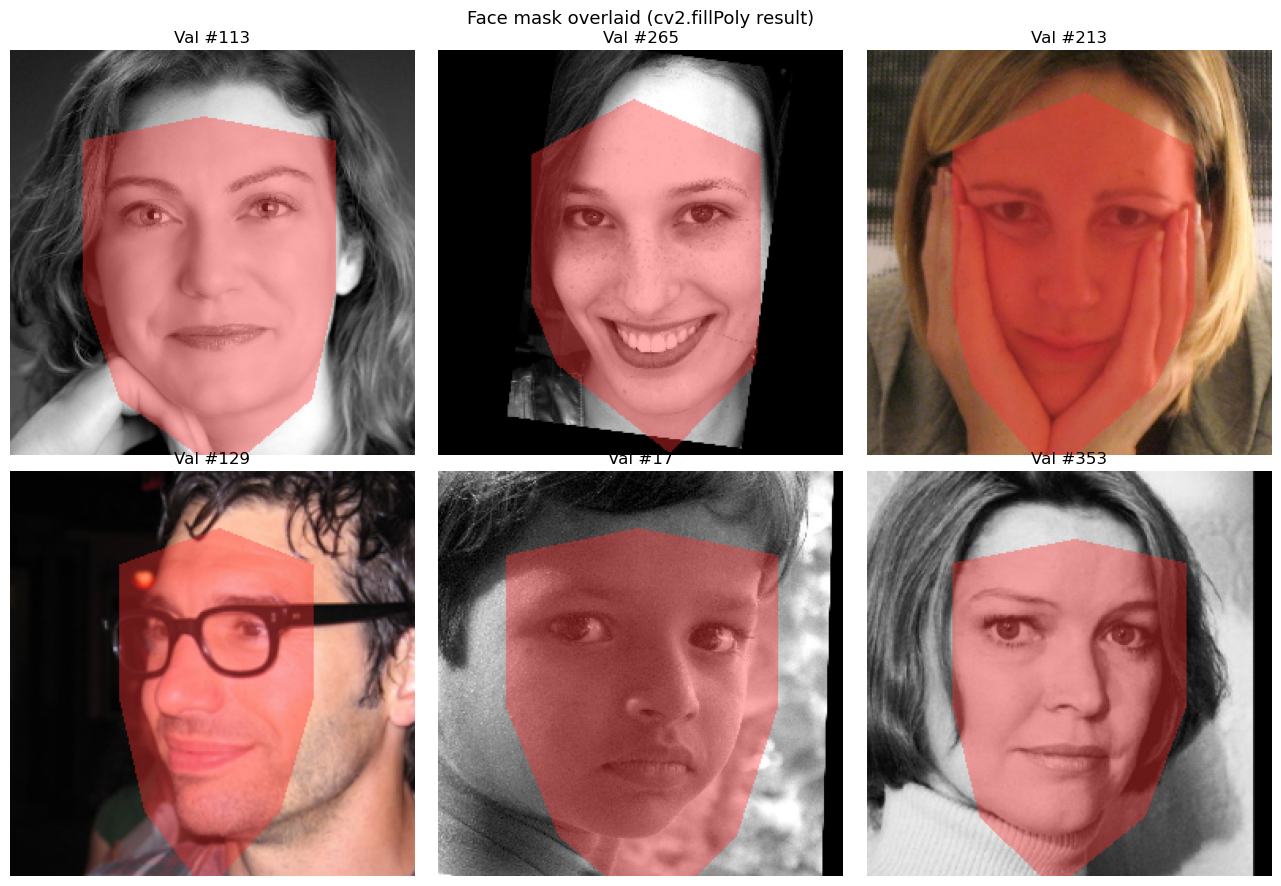

In [4]:
# === Cell 4: Visualise binary mask on the same 6 images ===
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, i in zip(axes.flat, sample):
    img = X_val[i]
    mask = segment.face_polygon_mask(img.shape, y_pred_val[i])

    # Show image with mask overlaid in red
    overlay = img.copy()
    overlay[mask > 0] = (overlay[mask > 0] * 0.6 + np.array([255, 50, 50]) * 0.4).astype(np.uint8)

    ax.imshow(overlay)
    ax.set_title(f'Val #{i}')
    ax.axis('off')
fig.suptitle('Face mask overlaid (cv2.fillPoly result)', fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/16_face_mask.png',
            dpi=120, bbox_inches='tight')
plt.show()

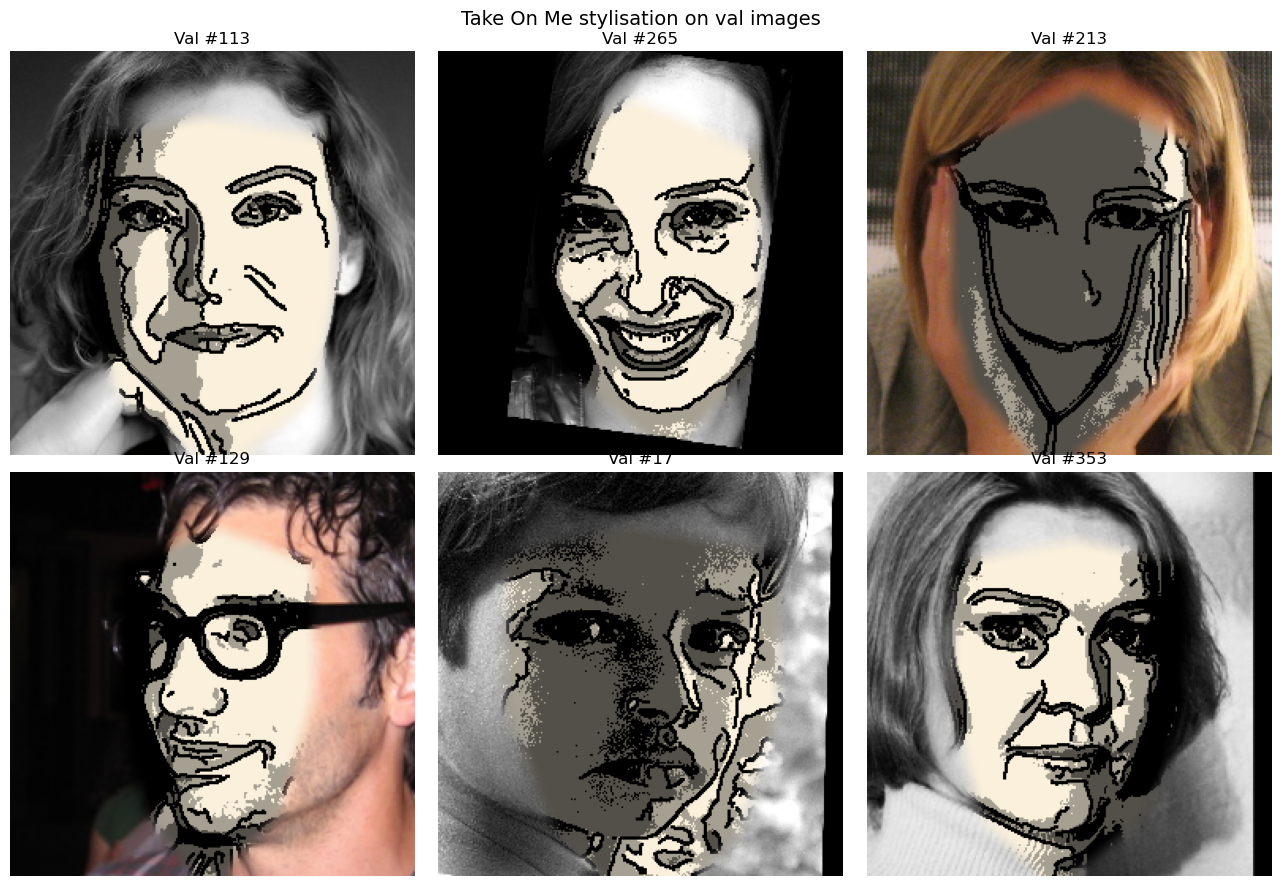

In [30]:
# === Cell 5: Apply Take On Me effect to the same 6 images ===
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, i in zip(axes.flat, sample):
    img = X_val[i]
    mask = segment.feathered_face_mask(img.shape, y_pred_val[i],
                                         feather_pixels=10)
    stylised = effects.take_on_me(img, mask)

    ax.imshow(stylised)
    ax.set_title(f'Val #{i}')
    ax.axis('off')
fig.suptitle('Take On Me stylisation on val images', fontsize=14)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/17_take_on_me.png',
            dpi=120, bbox_inches='tight')
plt.show()

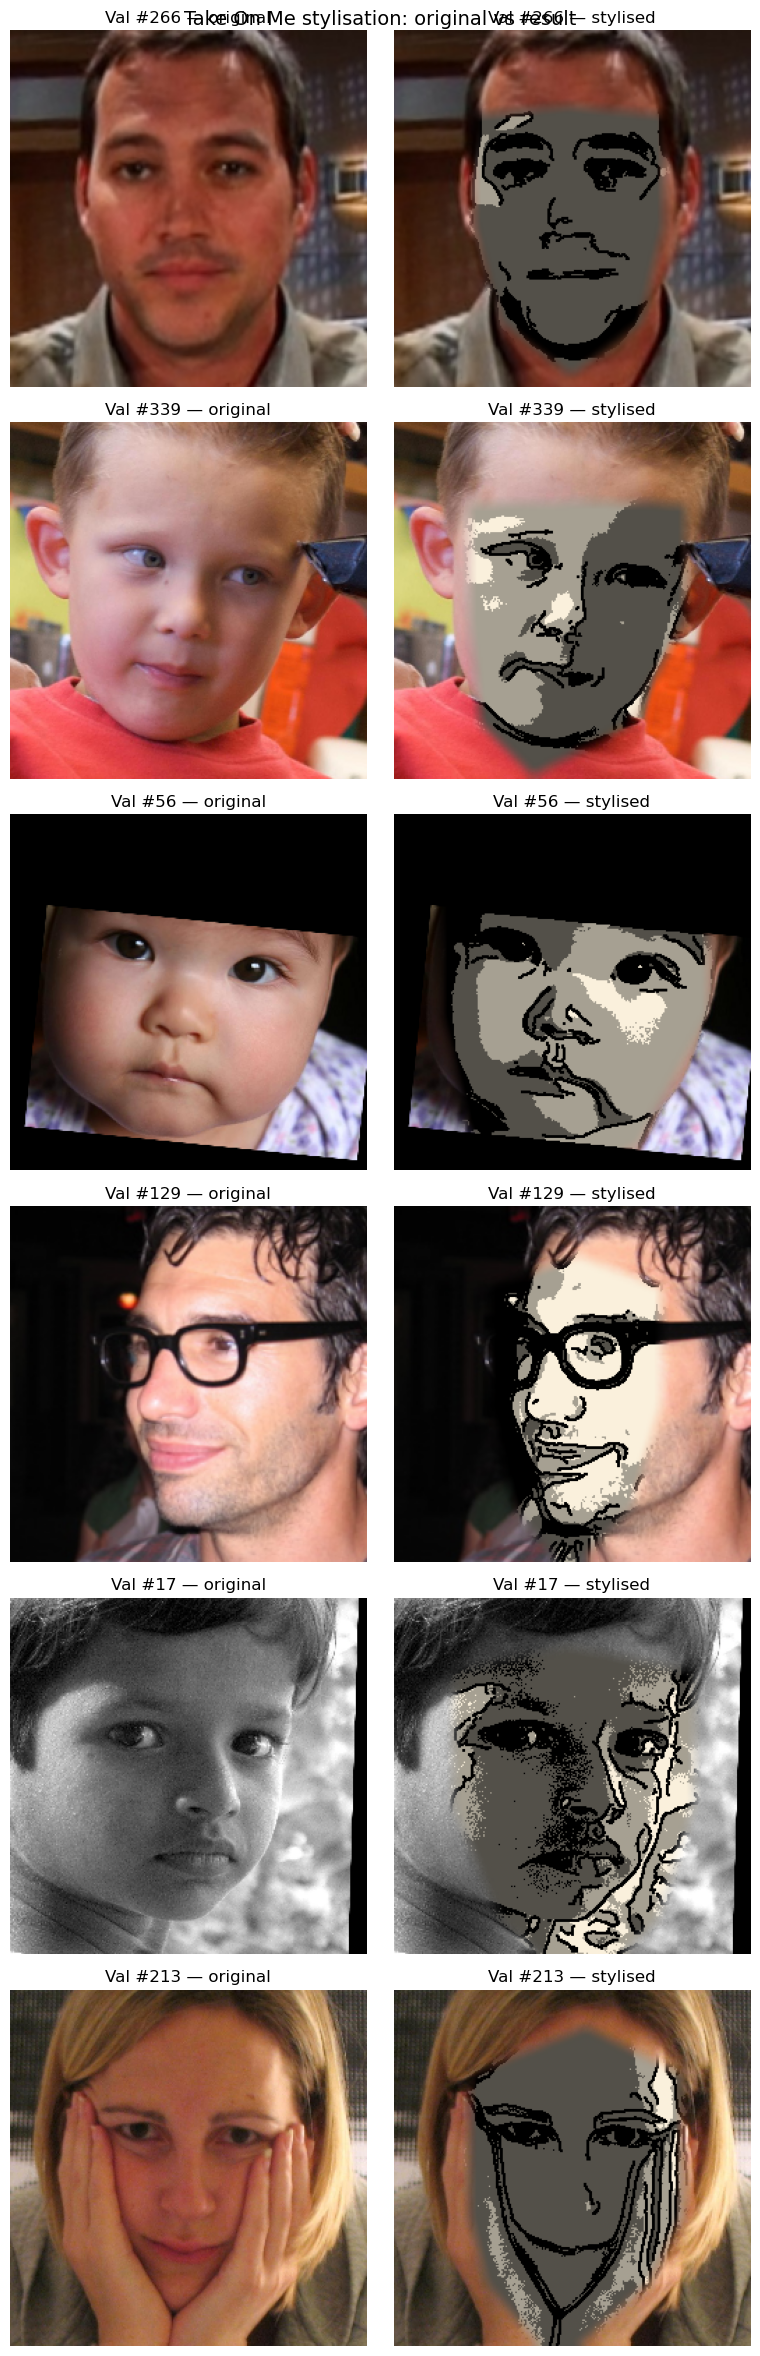

In [31]:
# === Cell 6: Side-by-side — original vs stylised, including a known failure case ===
# Pick a mix of cases: 3 confident, 1 profile, 1 dark, 1 child
chosen = [266, 339, 56, 129, 17, 213]  # mix of known good/hard cases from EDA

fig, axes = plt.subplots(len(chosen), 2, figsize=(8, 4 * len(chosen)))
for row, i in enumerate(chosen):
    img = X_val[i]
    mask = segment.feathered_face_mask(img.shape, y_pred_val[i], feather_pixels=10)
    stylised = effects.take_on_me(img, mask)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Val #{i} — original')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(stylised)
    axes[row, 1].set_title(f'Val #{i} — stylised')
    axes[row, 1].axis('off')

fig.suptitle('Take On Me stylisation: original vs result', fontsize=14)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/18_take_on_me_comparison.png',
            dpi=120, bbox_inches='tight')
plt.show()

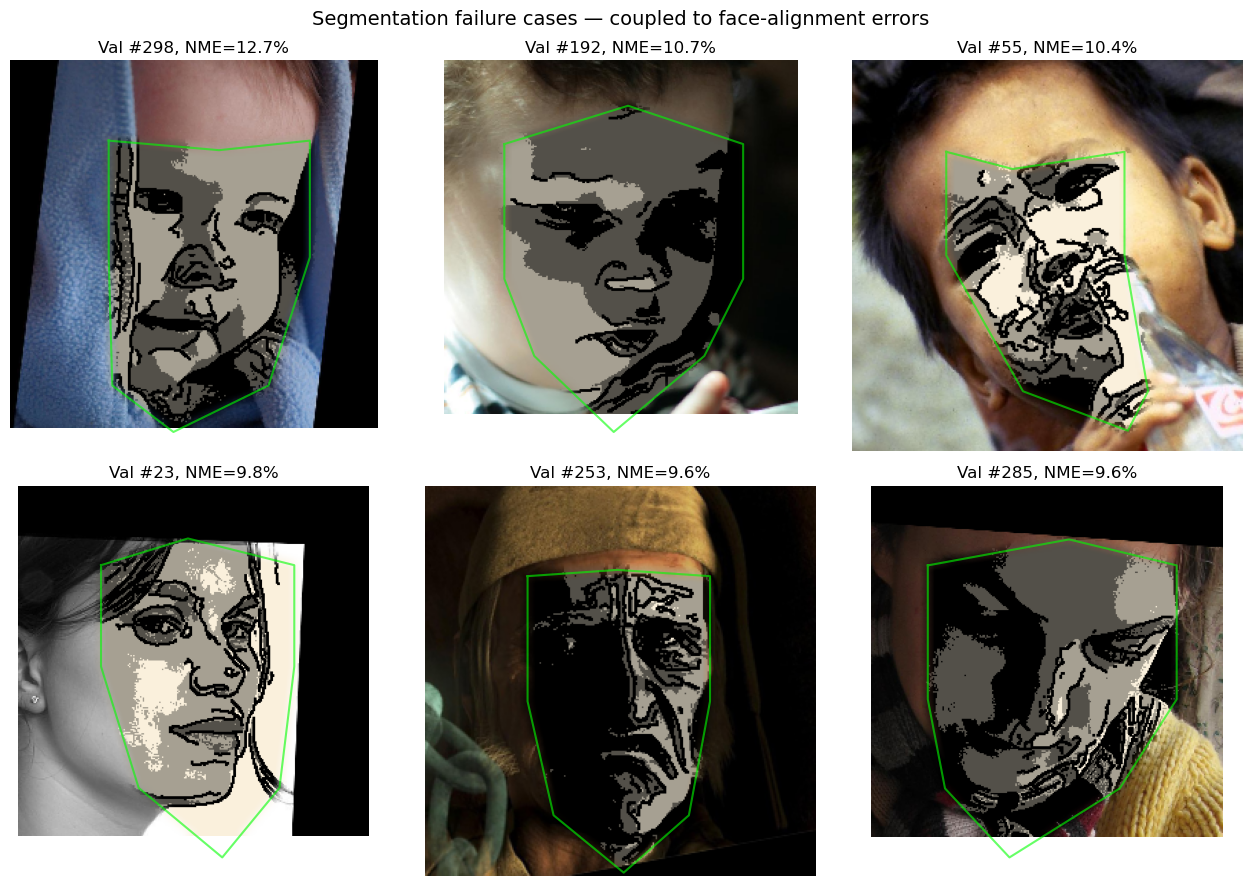

In [19]:
# === Cell 7: Segmentation failure cases ===
# A "failure" here means: bad face alignment → bad polygon → poor mask coverage.
# Find the val images where the cascade had high NME — those are where
# segmentation is most likely to go wrong.

from src import evaluate
nme_val = evaluate.nme(y_pred_val, y_val)
# Pick 6 worst cases by NME
worst_idx = np.argsort(nme_val)[-6:][::-1]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, i in zip(axes.flat, worst_idx):
    img = X_val[i]
    pts = y_pred_val[i]
    polygon = segment.face_polygon_points(pts)
    mask = segment.feathered_face_mask(img.shape, pts, feather_pixels=10)
    stylised = effects.take_on_me(img, mask)

    ax.imshow(stylised)
    poly_closed = np.vstack([polygon, polygon[:1]])
    ax.plot(poly_closed[:, 0], poly_closed[:, 1], 'lime', linewidth=1.5,
            alpha=0.6, label='polygon')
    ax.set_title(f'Val #{i}, NME={nme_val[i]*100:.1f}%')
    ax.axis('off')
fig.suptitle('Segmentation failure cases — coupled to face-alignment errors',
             fontsize=14)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/19_segmentation_failures.png',
            dpi=120, bbox_inches='tight')
plt.show()